# Benchmark: delnx vs R glmGamPoi

delnx reimplements [glmGamPoi](https://bioconductor.org/packages/release/bioc/html/glmGamPoi.html)'s
quasi-likelihood NB GLM approach in JAX. This notebook validates that the two implementations agree
on real data, and benchmarks runtime scaling across dataset sizes relevant to single-cell perturbation
screens.

In [1]:
import time

import delnx as dx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import pearsonr

## 1. Concordance on real data

We compare delnx and R glmGamPoi on a GLI3 KO pseudobulk dataset (28 samples, 16k genes)
to verify that dispersions, coefficients, and p-values agree.

In [2]:
adata = sc.read_h5ad("data/GLI3_KO_45d_pseudobulk.h5ad")
adata.obs["GLI3_KO"] = adata.obs["GLI3_KO"].astype(str)
counts = np.round(np.asarray(adata.layers["counts"])).astype(int)
adata.X = counts.astype(np.float64)

print(adata)
print(f"Conditions: {adata.obs['GLI3_KO'].value_counts().to_dict()}")

AnnData object with n_obs × n_vars = 28 × 16199
    obs: 'psbulk_replicate', 'cell_type', 'organoid', 'GLI3_KO', 'psbulk_cells', 'psbulk_counts', 'size_factor'
    var: 'dispersion', 'dispersion_deseq', 'dispersion_mle', 'dispersion_edger', 'mean', 'mean_norm'
    uns: 'log1p'
    layers: 'counts', 'psbulk_props'
Conditions: {'True': 16, 'False': 12}


In [3]:
fit_dx = dx.tl.nb_fit(adata, condition_key="GLI3_KO", reference="True")
res_dx = dx.tl.nb_test(adata, fit_dx, contrast="GLI3_KO[T.False]")
print(f"Significant genes (padj < 0.05): {(res_dx['padj'] < 0.05).sum()}")
res_dx.head()

INFO     Fitting 16199 genes with 2 coefficient(s)                                                                 


Fitting GLMs:   0%|          | 0/32 [00:00<?, ?it/s]

Fitting GLMs:   3%|▎         | 1/32 [00:03<01:58,  3.81s/it]

Fitting GLMs:  12%|█▎        | 4/32 [00:03<00:21,  1.33it/s]

Fitting GLMs:  22%|██▏       | 7/32 [00:04<00:09,  2.71it/s]

...

Fitting GLMs:  97%|█████████▋| 31/32 [00:04<00:00, 20.30it/s]

Fitting GLMs: 100%|██████████| 32/32 [00:08<00:00,  3.78it/s]

INFO     Applying quasi-likelihood shrinkage                                                                       


Significant genes (padj < 0.05): 181


,feature,log2fc,coef,stat,pval,padj
0,EMX1,6.761568,4.686762,83.710401,4.326881e-10,0.000007
1,ZNF429,-5.335782,-3.698482,75.925150,1.246159e-09,0.000010
2,SFTA3,-8.920224,-6.183028,60.244111,1.368526e-08,0.000074
3,CXXC4,-0.873021,-0.605132,54.949587,3.389955e-08,0.000106
4,ZIC5,1.904016,1.319763,54.774321,3.496747e-08,0.000106


In [4]:
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, pandas2ri, default_converter
from rpy2.robjects.packages import importr

converter = default_converter + numpy2ri.converter + pandas2ri.converter
_ctx = converter.context()
_ctx.__enter__()

base = importr("base")
glmGamPoi = importr("glmGamPoi")
print(f"R version: {base.R_version_string[0]}")

R version: R version 4.5.3 (2026-03-11)


In [5]:
ro.globalenv["counts"] = counts.T
ro.globalenv["condition"] = ro.FactorVector(
    adata.obs["GLI3_KO"].values, levels=ro.StrVector(["True", "False"]))
ro.globalenv["gene_names"] = ro.StrVector(adata.var_names.tolist())
ro.globalenv["sample_names"] = ro.StrVector(adata.obs_names.tolist())

ro.r('''
rownames(counts) <- gene_names
colnames(counts) <- sample_names
col_data <- data.frame(GLI3_KO = condition, row.names = sample_names)
fit_gp <- glm_gp(counts, design = ~ GLI3_KO, col_data = col_data,
                  size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
res_gp <- test_de(fit_gp, contrast = cond(GLI3_KO = "False") - cond(GLI3_KO = "True"))
''')

res_glmgp = pd.DataFrame({
    "feature": np.array(ro.r("res_gp$name")),
    "log2fc": np.array(ro.r("res_gp$lfc")),
    "pval": np.array(ro.r("res_gp$pval")),
    "padj": np.array(ro.r("res_gp$adj_pval")),
})
disp_glmgp = np.array(ro.r("fit_gp$overdispersions"))

print(f"Significant genes (padj < 0.05): {(res_glmgp['padj'] < 0.05).sum()}")
res_glmgp.head()

Significant genes (padj < 0.05): 187


,feature,log2fc,pval,padj
0,LRP6,-0.293760,0.007480,0.204735
1,PDCL2,-0.445917,0.447408,0.855558
2,PRSS56,-0.820560,0.189395,0.723788
3,ZNF665,0.306711,0.138165,0.670246
4,WDR3,-0.083624,0.433192,0.847047


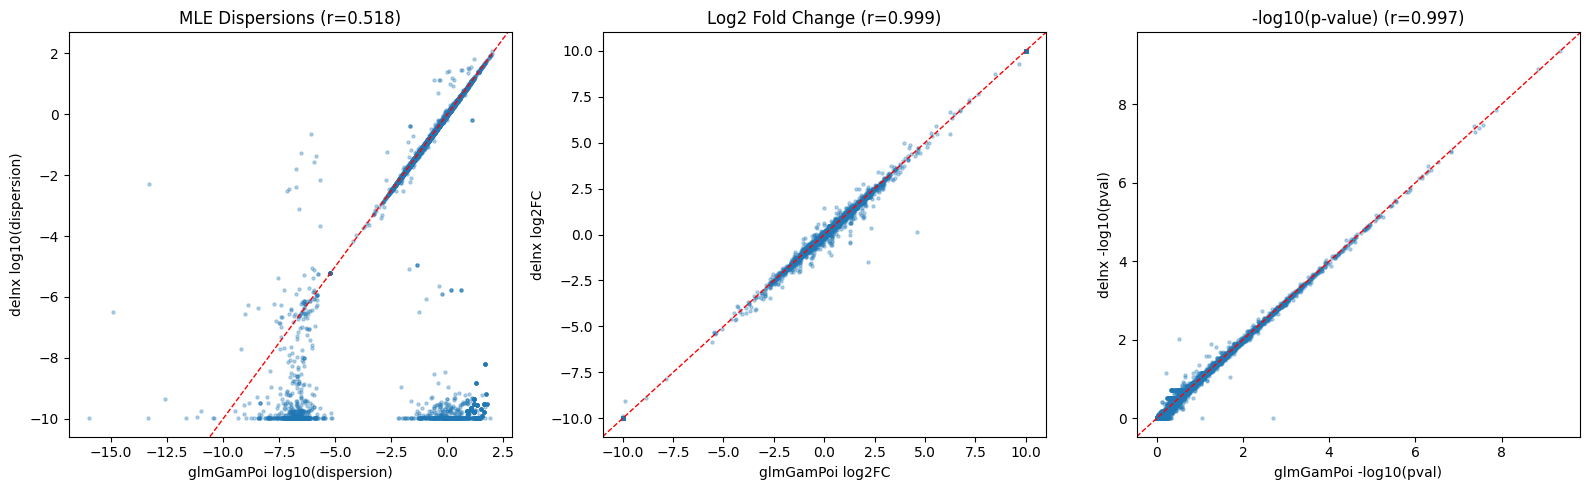

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Dispersions
ax = axes[0]
d1, d2 = fit_dx.overdispersions, disp_glmgp
mask = (d1 > 0) & (d2 > 0) & np.isfinite(d1) & np.isfinite(d2)
ax.scatter(np.log10(d2[mask]), np.log10(d1[mask]), s=5, alpha=0.3)
ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
r, _ = pearsonr(np.log10(d2[mask]), np.log10(d1[mask]))
ax.set_xlabel("glmGamPoi log10(dispersion)")
ax.set_ylabel("delnx log10(dispersion)")
ax.set_title(f"MLE Dispersions (r={r:.3f})")

# LFC
ax = axes[1]
lfc_dx = res_dx.set_index("feature")["log2fc"]
lfc_gp = res_glmgp.set_index("feature")["log2fc"]
common = lfc_dx.index.intersection(lfc_gp.index)
l1, l2 = lfc_dx[common].dropna(), lfc_gp[common].dropna()
common2 = l1.index.intersection(l2.index)
r, _ = pearsonr(l1[common2], l2[common2])
ax.scatter(l2[common2], l1[common2], s=5, alpha=0.3)
ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("glmGamPoi log2FC")
ax.set_ylabel("delnx log2FC")
ax.set_title(f"Log2 Fold Change (r={r:.3f})")

# P-values
ax = axes[2]
p_dx = res_dx.set_index("feature")["pval"]
p_gp = res_glmgp.set_index("feature")["pval"]
p1, p2 = p_dx[common].dropna(), p_gp[common].dropna()
common3 = p1.index.intersection(p2.index)
p1v, p2v = p1[common3].replace(0, np.nan).dropna(), p2[common3].replace(0, np.nan).dropna()
common4 = p1v.index.intersection(p2v.index)
r, _ = pearsonr(-np.log10(p1v[common4]), -np.log10(p2v[common4]))
ax.scatter(-np.log10(p2v[common4]), -np.log10(p1v[common4]), s=5, alpha=0.3)
ax.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("glmGamPoi -log10(pval)")
ax.set_ylabel("delnx -log10(pval)")
ax.set_title(f"-log10(p-value) (r={r:.3f})")

plt.tight_layout()
plt.show()
plt.close()

In [7]:
padj_dx = res_dx.set_index("feature")["padj"]
padj_gp = res_glmgp.set_index("feature")["padj"]
common_padj = padj_dx.dropna().index.intersection(padj_gp.dropna().index)

sig_dx = set(common_padj[padj_dx[common_padj] < 0.05])
sig_gp = set(common_padj[padj_gp[common_padj] < 0.05])
jaccard = len(sig_dx & sig_gp) / len(sig_dx | sig_gp) if len(sig_dx | sig_gp) > 0 else 0

print(f"delnx significant:    {len(sig_dx)}")
print(f"glmGamPoi significant: {len(sig_gp)}")
print(f"Shared:               {len(sig_dx & sig_gp)}")
print(f"Jaccard index:        {jaccard:.3f}")

delnx significant:    181
glmGamPoi significant: 187
Shared:               181
Jaccard index:        0.968


## 2. Runtime scaling

We benchmark delnx vs R glmGamPoi on simulated pseudobulk data, varying the number of
conditions and samples per condition independently. Genes are fixed at 20,000.

For delnx, we report **warm** times (JAX JIT cache populated) since the one-time compilation
overhead (~5s) is amortized across analyses in a session.

In [8]:
import anndata as ad


def simulate_pseudobulk(n_genes, n_conditions, n_samples_per_condition, mean_counts=100, dispersion=0.5, seed=42):
    """Simulate pseudobulk NB counts for a multi-condition experiment."""
    rng = np.random.default_rng(seed)
    n_samples = n_conditions * n_samples_per_condition

    gene_means = rng.lognormal(np.log(mean_counts), 1.0, size=n_genes)
    size_factors = rng.lognormal(0, 0.2, size=n_samples)

    # Vectorized NB sampling
    r = 1.0 / dispersion
    mu = gene_means[None, :] * size_factors[:, None]  # (n_samples, n_genes)
    p = r / (r + mu)
    counts = rng.negative_binomial(r, p)

    # Condition labels
    labels = [f"cond_{i}" for i in range(n_conditions) for _ in range(n_samples_per_condition)]

    adata_sim = ad.AnnData(X=counts.astype(np.float64))
    adata_sim.var_names = [f"gene_{i}" for i in range(n_genes)]
    adata_sim.obs_names = [f"sample_{i}" for i in range(n_samples)]
    adata_sim.obs["condition"] = labels
    return adata_sim


print("Simulation function defined")

Simulation function defined


In [9]:
# Warm up JAX JIT cache
adata_warmup = simulate_pseudobulk(1000, 2, 3)
fit_warmup = dx.tl.nb_fit(adata_warmup, condition_key="condition", reference="cond_0", verbose=False)
_ = dx.tl.nb_test(adata_warmup, fit_warmup, contrast="condition[T.cond_1]")
print("JIT warmup complete")

JIT warmup complete


### 2.1 Scaling with number of conditions

Fixed: 20,000 genes, 3 samples per condition. Vary conditions from 2 to 100.
This covers the range from simple two-group comparisons to perturbation screens.

> **Note:** Larger designs (200+ conditions) exceed single-GPU memory for the default batch size.
> For very large perturbation screens, we plan to add automatic batch size tuning in a future release.

In [10]:
N_GENES = 20000
N_SAMPLES_PER = 3
condition_counts = [2, 5, 10, 20, 50, 100]

cond_results = []

for n_cond in condition_counts:
    n_total = n_cond * N_SAMPLES_PER
    print(f"\n--- {n_cond} conditions, {n_total} samples, {n_cond} coefficients ---")

    adata_sim = simulate_pseudobulk(N_GENES, n_cond, N_SAMPLES_PER)

    # delnx
    t0 = time.time()
    fit_sim = dx.tl.nb_fit(adata_sim, condition_key="condition", reference="cond_0", verbose=False)
    _ = dx.tl.nb_test(adata_sim, fit_sim, contrast=fit_sim.design_column_names[1])
    t_dx = time.time() - t0
    cond_results.append({"n_conditions": n_cond, "n_samples": n_total, "method": "delnx", "time": t_dx})
    print(f"  delnx:     {t_dx:.1f}s")

    # R glmGamPoi
    c_sim = np.round(np.asarray(adata_sim.X)).astype(int)
    ro.globalenv["sim_counts"] = c_sim.T
    levels = [f"cond_{i}" for i in range(n_cond)]
    ro.globalenv["sim_cond"] = ro.FactorVector(adata_sim.obs["condition"].values, levels=ro.StrVector(levels))
    ro.globalenv["sim_genes"] = ro.StrVector(adata_sim.var_names.tolist())
    ro.globalenv["sim_samples"] = ro.StrVector(adata_sim.obs_names.tolist())
    t0 = time.time()
    ro.r('''
    rownames(sim_counts) <- sim_genes; colnames(sim_counts) <- sim_samples
    sim_col <- data.frame(condition = sim_cond, row.names = sim_samples)
    sim_fit <- glm_gp(sim_counts, design = ~ condition, col_data = sim_col,
                      size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
    sim_res <- test_de(sim_fit, contrast = cond(condition = "cond_1") - cond(condition = "cond_0"))
    ''')
    t_gp = time.time() - t0
    cond_results.append({"n_conditions": n_cond, "n_samples": n_total, "method": "glmGamPoi", "time": t_gp})
    print(f"  glmGamPoi: {t_gp:.1f}s")

cond_df = pd.DataFrame(cond_results)
print("\n" + cond_df.pivot_table(index="n_conditions", columns="method", values="time").to_string())


--- 2 conditions, 6 samples, 2 coefficients ---


  delnx:     6.6s


  glmGamPoi: 11.3s

--- 5 conditions, 15 samples, 5 coefficients ---


  delnx:     10.8s


R callback write-console: In addition:   


...

  glmGamPoi: 21.1s

--- 50 conditions, 150 samples, 50 coefficients ---


  delnx:     21.5s


  glmGamPoi: 50.0s

--- 100 conditions, 300 samples, 100 coefficients ---


  delnx:     52.9s


  glmGamPoi: 173.6s

method            delnx   glmGamPoi
n_conditions                       
2              6.562621   11.264031
5             10.750736   11.373775
10            12.315487   12.872324
20            12.042035   21.120112
50            21.546143   50.009611
100           52.923068  173.644198


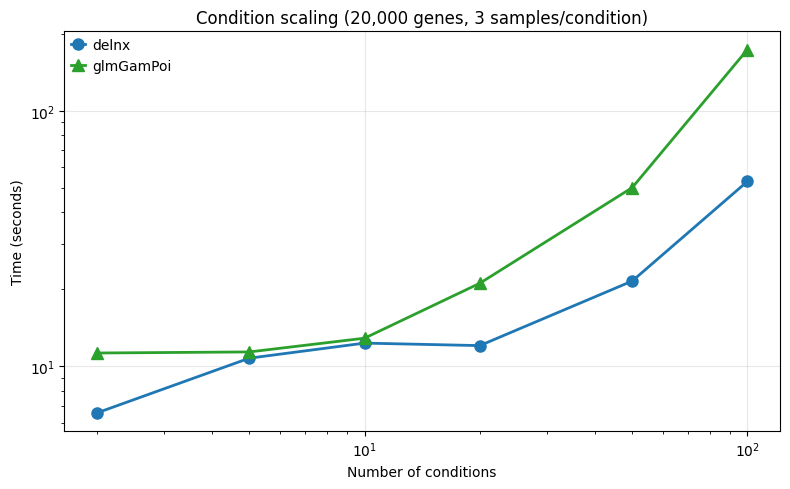

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for method, style in [("delnx", dict(color="#1f77b4", marker="o")), ("glmGamPoi", dict(color="#2ca02c", marker="^"))]:
    sub = cond_df[cond_df["method"] == method].sort_values("n_conditions")
    ax.plot(sub["n_conditions"], sub["time"], label=method, linewidth=2, markersize=8, **style)

ax.set_xlabel("Number of conditions")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Condition scaling ({N_GENES:,} genes, {N_SAMPLES_PER} samples/condition)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

### 2.2 Scaling with samples per condition

Fixed: 20,000 genes, 2 conditions. Vary samples per condition from 3 to 500.

In [12]:
N_COND = 2
samples_per = [3, 10, 50, 100, 500]

sample_results = []

for n_spc in samples_per:
    n_total = N_COND * n_spc
    print(f"\n--- {n_spc} samples/condition, {n_total} total samples ---")

    adata_sim = simulate_pseudobulk(N_GENES, N_COND, n_spc)

    # delnx
    t0 = time.time()
    fit_sim = dx.tl.nb_fit(adata_sim, condition_key="condition", reference="cond_0", verbose=False)
    _ = dx.tl.nb_test(adata_sim, fit_sim, contrast="condition[T.cond_1]")
    t_dx = time.time() - t0
    sample_results.append({"n_samples_per": n_spc, "n_samples": n_total, "method": "delnx", "time": t_dx})
    print(f"  delnx:     {t_dx:.1f}s")

    # R glmGamPoi
    c_sim = np.round(np.asarray(adata_sim.X)).astype(int)
    ro.globalenv["sim_counts"] = c_sim.T
    ro.globalenv["sim_cond"] = ro.FactorVector(
        adata_sim.obs["condition"].values, levels=ro.StrVector(["cond_0", "cond_1"]))
    ro.globalenv["sim_genes"] = ro.StrVector(adata_sim.var_names.tolist())
    ro.globalenv["sim_samples"] = ro.StrVector(adata_sim.obs_names.tolist())
    t0 = time.time()
    ro.r('''
    rownames(sim_counts) <- sim_genes; colnames(sim_counts) <- sim_samples
    sim_col <- data.frame(condition = sim_cond, row.names = sim_samples)
    sim_fit <- glm_gp(sim_counts, design = ~ condition, col_data = sim_col,
                      size_factors = "normed_sum", overdispersion_shrinkage = TRUE)
    sim_res <- test_de(sim_fit, contrast = cond(condition = "cond_1") - cond(condition = "cond_0"))
    ''')
    t_gp = time.time() - t0
    sample_results.append({"n_samples_per": n_spc, "n_samples": n_total, "method": "glmGamPoi", "time": t_gp})
    print(f"  glmGamPoi: {t_gp:.1f}s")

sample_df = pd.DataFrame(sample_results)
print("\n" + sample_df.pivot_table(index="n_samples_per", columns="method", values="time").to_string())


--- 3 samples/condition, 6 total samples ---


  delnx:     2.2s


  glmGamPoi: 10.6s

--- 10 samples/condition, 20 total samples ---


  delnx:     10.1s


  glmGamPoi: 12.4s

--- 50 samples/condition, 100 total samples ---


...

  glmGamPoi: 17.8s

--- 100 samples/condition, 200 total samples ---


  delnx:     10.3s


  glmGamPoi: 22.3s

--- 500 samples/condition, 1000 total samples ---


  delnx:     16.9s


  glmGamPoi: 42.3s

method             delnx  glmGamPoi
n_samples_per                      
3               2.248301  10.625952
10             10.094834  12.387680
50             11.291383  17.837534
100            10.285260  22.291306
500            16.888651  42.323591


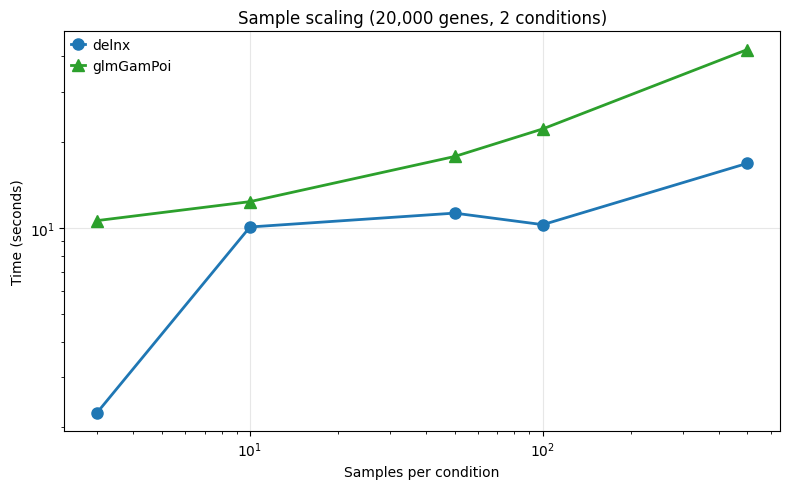

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

for method, style in [("delnx", dict(color="#1f77b4", marker="o")), ("glmGamPoi", dict(color="#2ca02c", marker="^"))]:
    sub = sample_df[sample_df["method"] == method].sort_values("n_samples_per")
    ax.plot(sub["n_samples_per"], sub["time"], label=method, linewidth=2, markersize=8, **style)

ax.set_xlabel("Samples per condition")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Sample scaling ({N_GENES:,} genes, {N_COND} conditions)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()